In [3]:
# Install required packages (if not already installed)
%pip install scikit-learn xgboost shap optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, auc
import xgboost as xgb
import shap
import optuna


Note: you may need to restart the kernel to use updated packages.


j:\python\streamlit\Streamlit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA INSPECTION

In [4]:
df = pd.read_csv("Loan_approval_data_2025.csv")

df

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0


In [5]:
df.shape

(50000, 20)

In [6]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [8]:
df.tail()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0
49999,CUST149999,53,Employed,17.2,46923,695,15.0,8332,2655,0,1,0,Personal Loan,Personal,41000,12.39,0.057,0.874,0.291,1


In [9]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [10]:
df.isnull().sum()

customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

In [11]:
df['age'].unique()

array([40, 33, 42, 53, 32, 44, 29, 41, 37, 18, 28, 22, 38, 24, 52, 35, 36,
       21, 39, 27, 31, 57, 34, 20, 19, 43, 26, 47, 30, 46, 51, 25, 45, 64,
       48, 61, 23, 50, 67, 70, 62, 60, 56, 54, 49, 59, 58, 55, 65, 66, 63,
       68, 69])

In [12]:
df['derogatory_marks'].unique()

array([0, 2, 1, 3, 4])

In [13]:
df['occupation_status'].unique()

array(['Employed', 'Student', 'Self-Employed'], dtype=object)

In [14]:
df['loan_intent'].unique()

array(['Business', 'Home Improvement', 'Debt Consolidation', 'Education',
       'Personal', 'Medical'], dtype=object)

In [15]:
df['product_type'].unique()

array(['Credit Card', 'Personal Loan', 'Line of Credit'], dtype=object)

In [16]:
df['delinquencies_last_2yrs'].unique()

array([0, 1, 2, 4, 3, 5, 8, 6, 7, 9])

In [17]:
df['defaults_on_file'].unique()

array([0, 1])

In [18]:
df['loan_status'].unique()

array([1, 0])

In [19]:
df['derogatory_marks'].unique()

array([0, 2, 1, 3, 4])

In [20]:
df.drop_duplicates()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0


# DATA CLEANING

In [21]:
label_encoder = LabelEncoder()

# Drop customer_id as it's an identifier and not a feature
df = df.drop('customer_id', axis=1)

# Apply LabelEncoder to categorical columns
df['occupation_status'] = label_encoder.fit_transform(df['occupation_status'])
df['product_type'] = label_encoder.fit_transform(df['product_type'])
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])

In [22]:
df

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,0,17.2,25579,692,5.3,895,10820,0,0,0,0,0,600,17.02,0.423,0.023,0.008,1
1,33,0,7.3,43087,627,3.5,169,16550,0,1,0,2,3,53300,14.10,0.384,1.237,0.412,0
2,42,2,1.1,20840,689,8.4,17,7852,0,0,0,0,1,2100,18.33,0.377,0.101,0.034,1
3,53,2,0.5,29147,692,9.8,1480,11603,0,1,0,0,0,2900,18.74,0.398,0.099,0.033,1
4,32,0,12.5,63657,630,7.2,209,12424,0,0,0,2,2,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,35,0,4.3,39449,570,16.3,1127,7576,0,0,0,0,2,42800,21.31,0.192,1.085,0.362,0
49996,34,0,4.4,20496,672,12.6,1478,6276,1,0,0,0,5,3800,18.07,0.306,0.185,0.062,0
49997,41,1,4.8,18743,719,10.1,17,10331,0,0,0,0,5,18000,17.45,0.551,0.960,0.320,0
49998,38,2,0.4,17250,633,1.3,5,7779,0,0,1,2,5,1400,14.71,0.451,0.081,0.027,0


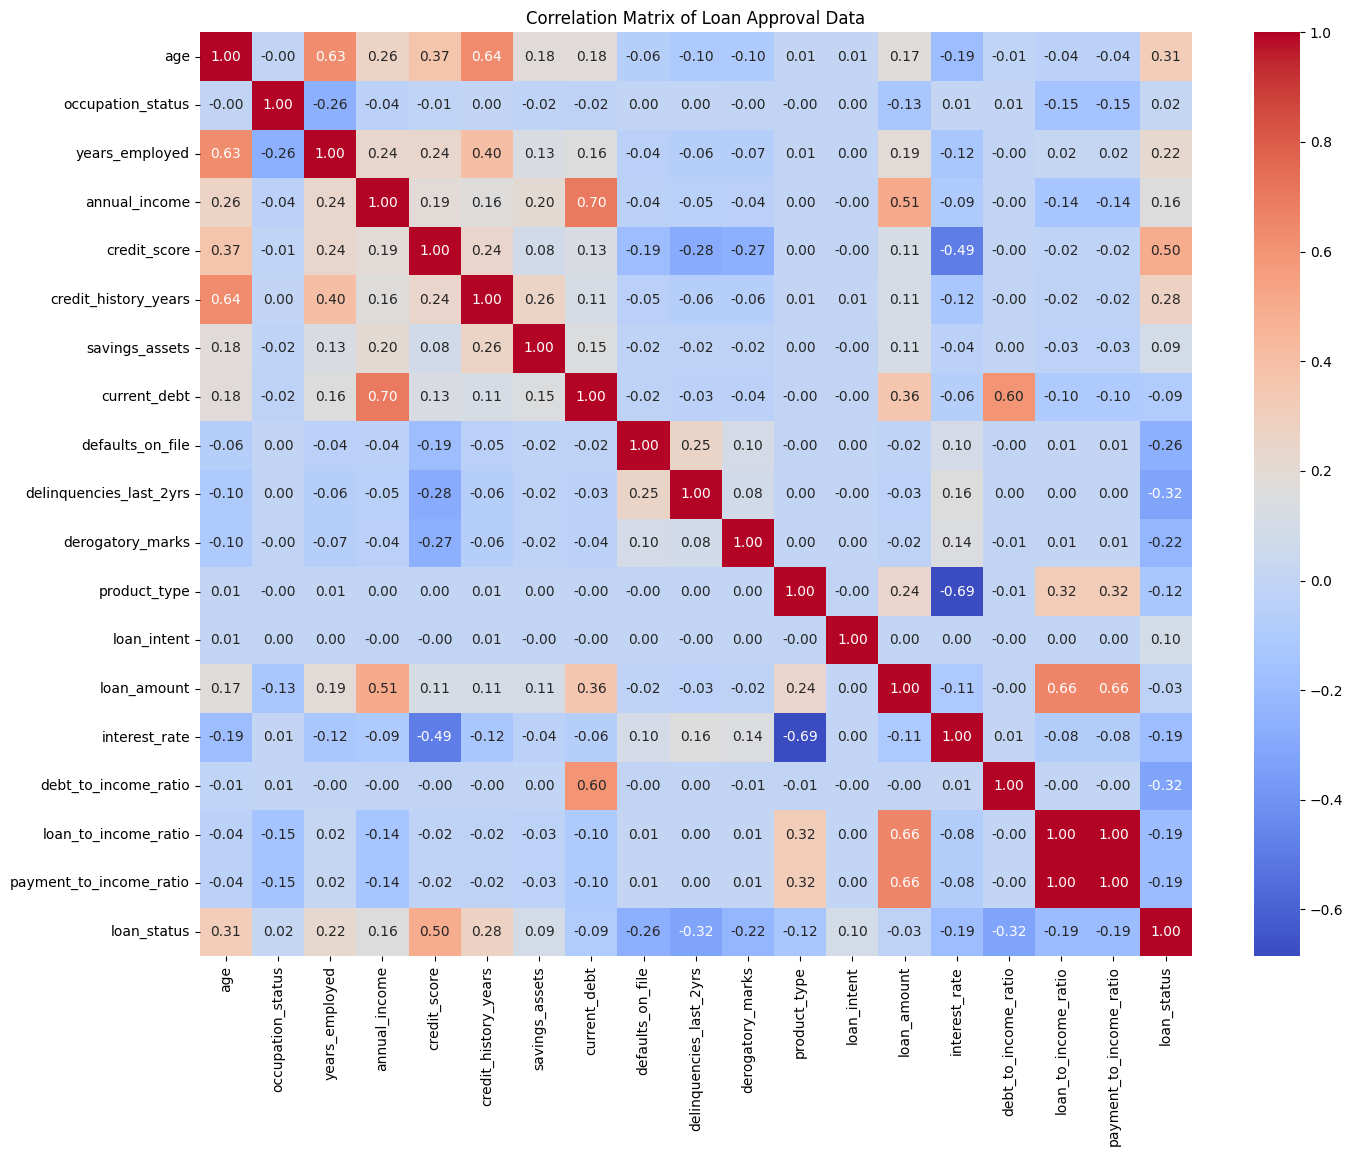

In [23]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix of Loan Approval Data')
plt.show()

In [24]:
df = df.drop(columns=[
    "occupation_status",
    "debt_to_income_ratio",
    "derogatory_marks",
    "interest_rate",
    "loan_to_income_ratio",
    "age",
    "current_debt",
    "payment_to_income_ratio"
])

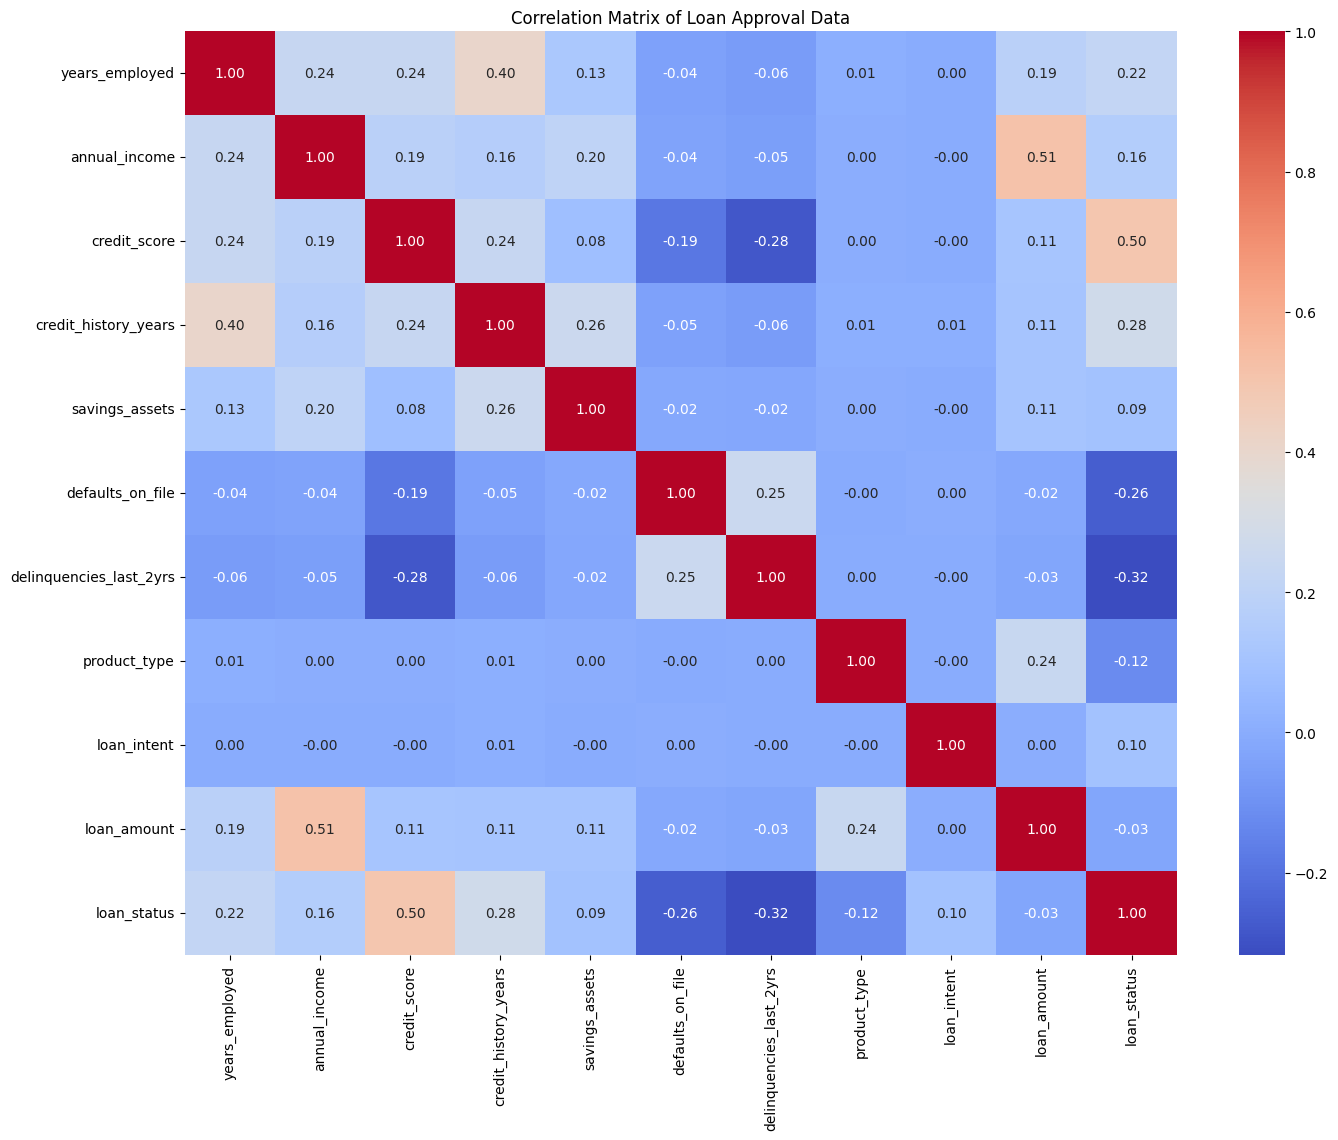

In [25]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix of Loan Approval Data')
plt.show()

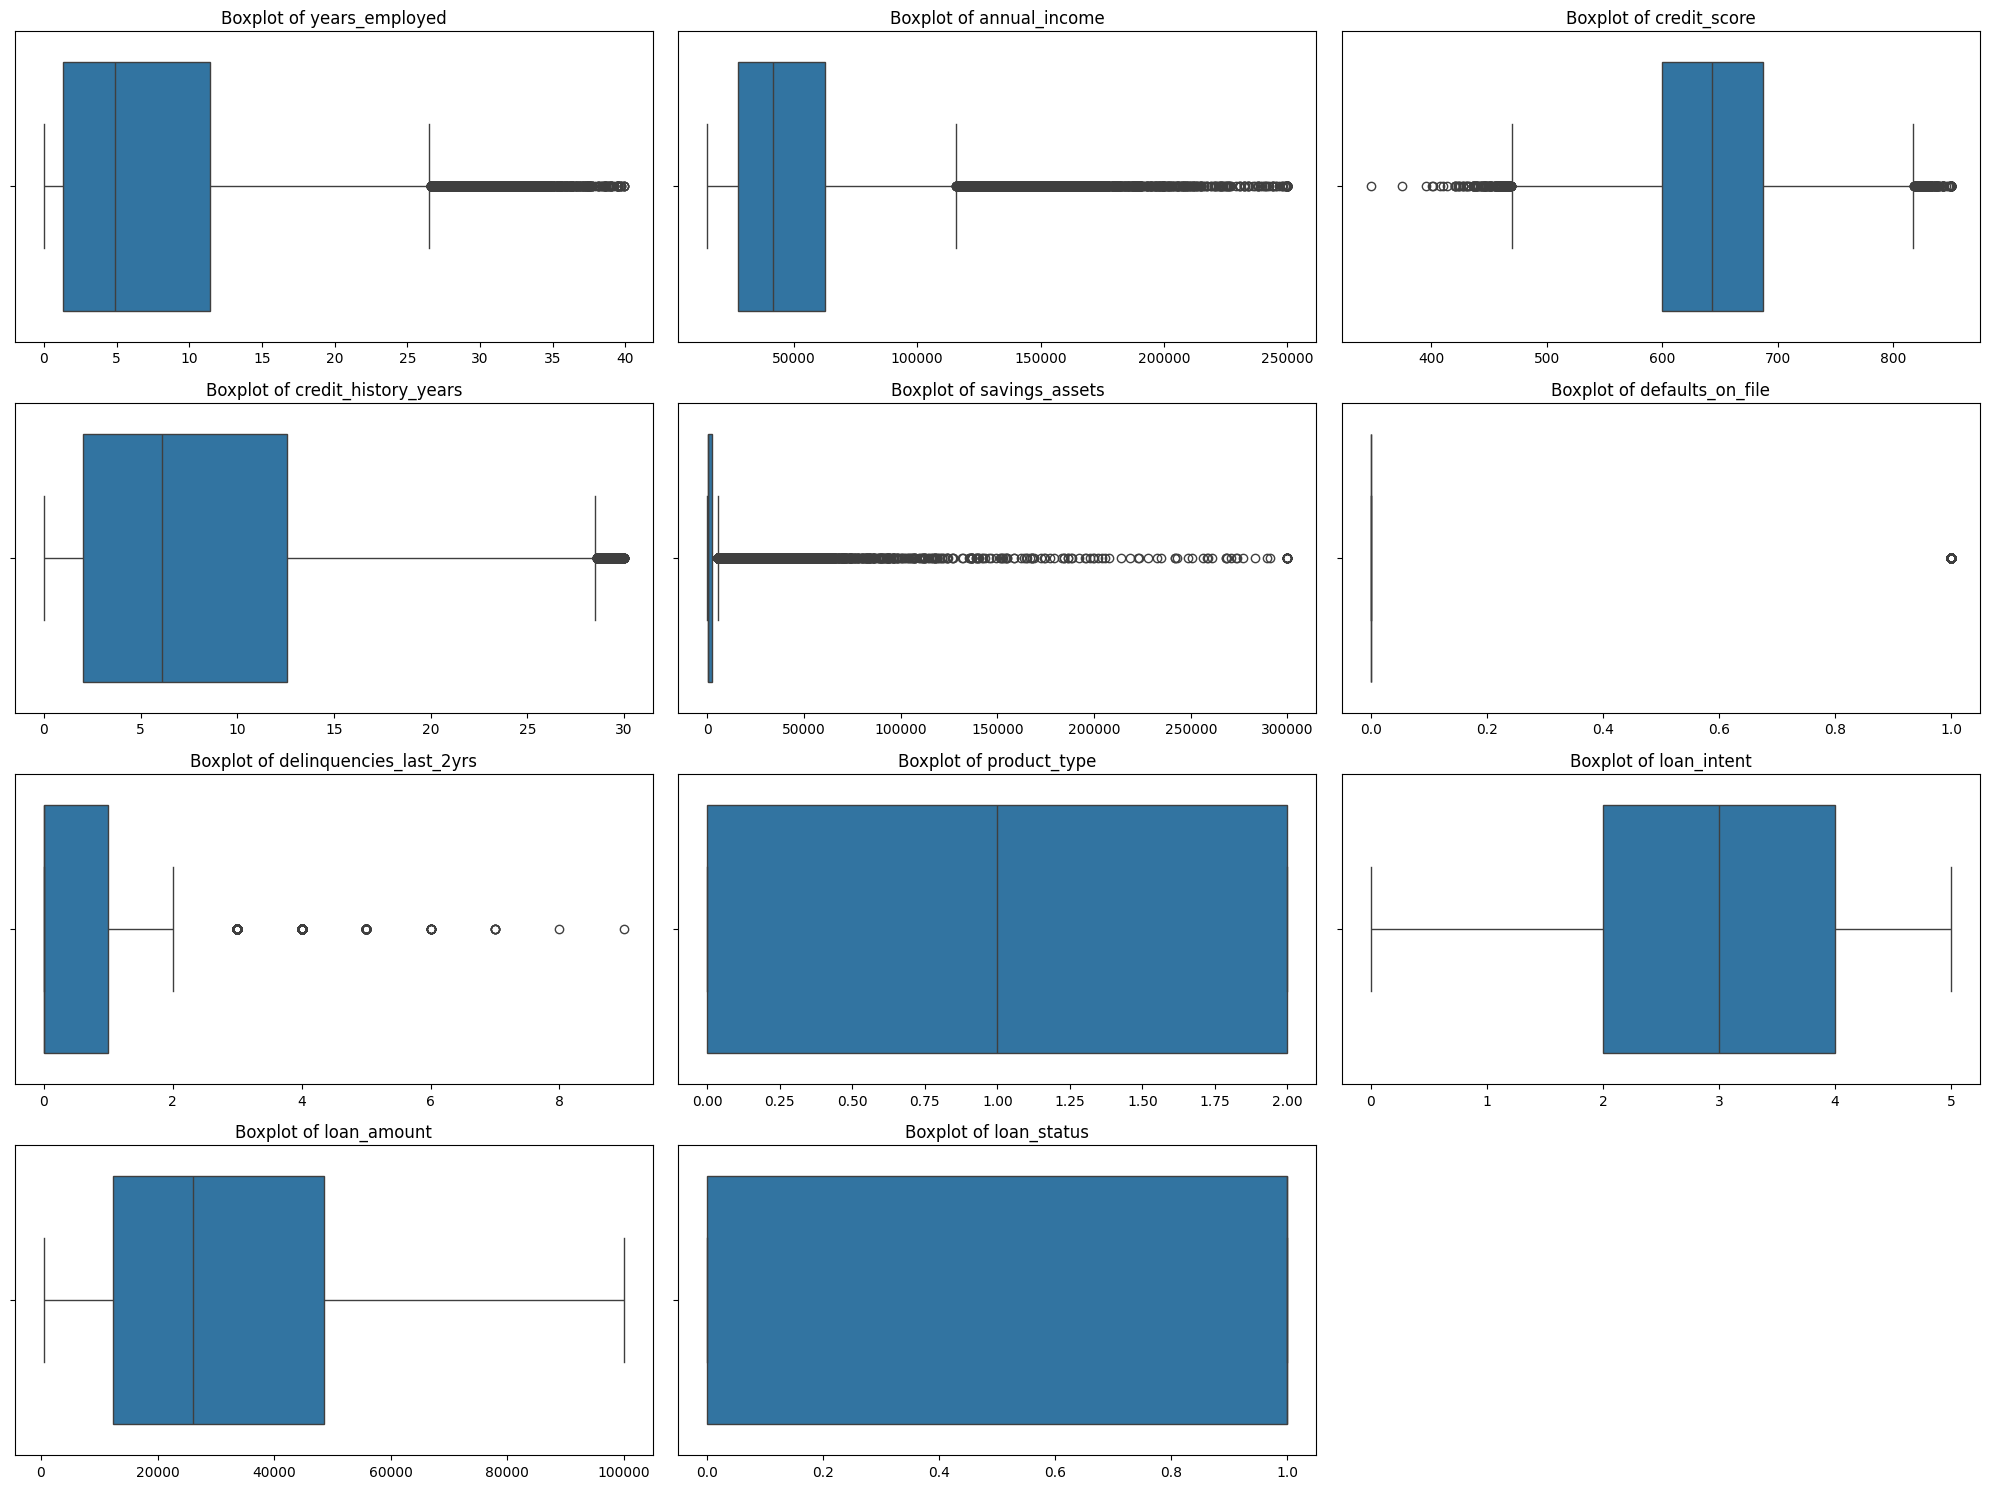

In [26]:
plt.figure(figsize=(20, 15))
num_cols = len(df.columns)
num_rows = (num_cols + 2) // 3 # Adjust rows based on number of columns for better layout

for i, column in enumerate(df.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

In [27]:
# 2. One-Hot Encoding for categorical variables
# (occupation_status, product_type, loan_intent)
df_encoded = pd.get_dummies(df, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']
df.head()

,years_employed,annual_income,credit_score,credit_history_years,savings_assets,defaults_on_file,delinquencies_last_2yrs,product_type,loan_intent,loan_amount,loan_status
0,17.2,25579,692,5.3,895,0,0,0,0,600,1
1,7.3,43087,627,3.5,169,0,1,2,3,53300,0
2,1.1,20840,689,8.4,17,0,0,0,1,2100,1
3,0.5,29147,692,9.8,1480,0,1,0,0,2900,1
4,12.5,63657,630,7.2,209,0,0,2,2,99600,1


In [28]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [31]:
# 1. Initialize and Train the model for Logistic Regression
log_reg_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)

# 2. Make predictions on the unseen test set
y_pred_log = log_reg_model.predict(X_test_scaled)
log_cm = confusion_matrix(y_test, y_pred_log)

In [32]:
# 1. Initialize the XGBoost model
# We use standard hyperparameters that usually work well for this type of data
xgb_model = xgb.XGBClassifier(
    random_state=42,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    eval_metric='logloss'
)

# 2. Train the model
# (Make sure to use your training data here, e.g., X_train, y_train
# or X_train_resampled, y_train_resampled if you used SMOTE)
xgb_model.fit(X_train_resampled, y_train_resampled)

# 3. Make predictions on your test set
y_pred_xgb = xgb_model.predict(X_test_scaled) # Use X_test if you didn't scale

In [33]:
# ----- L2 Regularization -----
log_l2_smot = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', class_weight='balanced')
log_l2_smot.fit(X_train_resampled, y_train_resampled)
print("L2 Accuracy SMOTE:", log_l2_smot.score(X_test_scaled, y_test))

# ----- L1 Regularization -----
log_l1_smot = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', class_weight='balanced')
log_l1_smot.fit(X_train_resampled, y_train_resampled)
print("L1 Accuracy SMOTE:", log_l1_smot.score(X_test_scaled, y_test))


j:\python\streamlit\Streamlit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
j:\python\streamlit\Streamlit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
j:\python\streamlit\Streamlit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Ple

L2 Accuracy SMOTE: 0.7877
L1 Accuracy SMOTE: 0.7877


In [34]:
# ----- XGBoost with L2 Regularization (reg_lambda) -----
xgb_l2 = xgb.XGBClassifier(random_state=42, learning_rate=0.1, max_depth=5, n_estimators=100, eval_metric='logloss', reg_lambda=1.0)
xgb_l2.fit(X_train_resampled, y_train_resampled)
print("XGBoost L2 Accuracy SMOTE:", xgb_l2.score(X_test_scaled, y_test))

# ----- XGBoost with L1 Regularization (reg_alpha) -----
xgb_l1 = xgb.XGBClassifier(random_state=42, learning_rate=0.1, max_depth=5, n_estimators=100, eval_metric='logloss', reg_alpha=1.0)
xgb_l1.fit(X_train_resampled, y_train_resampled)
print("XGBoost L1 Accuracy SMOTE:", xgb_l1.score(X_test_scaled, y_test))

XGBoost L2 Accuracy SMOTE: 0.8426
XGBoost L1 Accuracy SMOTE: 0.844


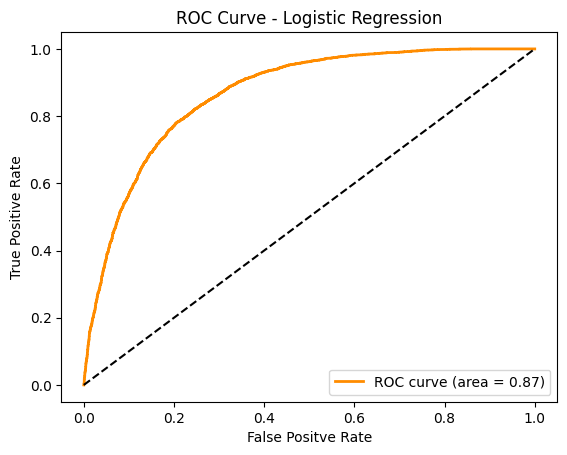

In [35]:
# ROC & AUC FOR LOGISTIC REGRESSION
y_true = y_test
y_pred_proba = log_reg_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--') #diagonal line
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

              precision    recall  f1-score   support

           0       0.76      0.78      0.77      4495
           1       0.81      0.80      0.81      5505

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



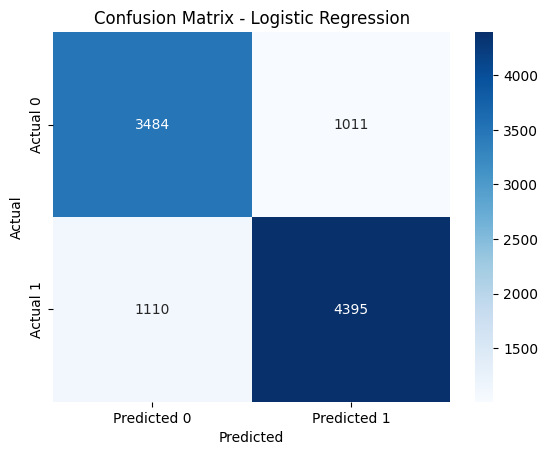

In [36]:
# Logistic Regression Classification Report

print(classification_report(y_test, y_pred_log))

sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

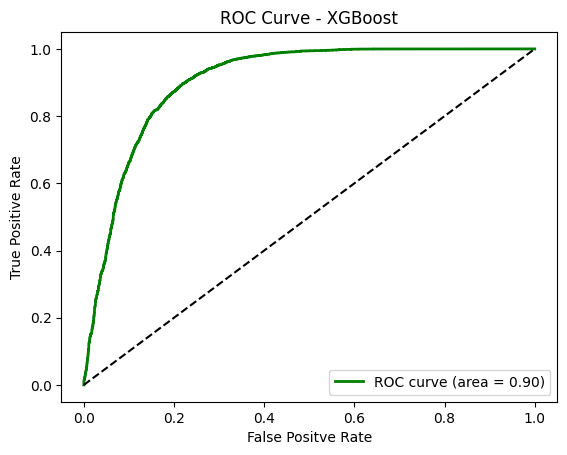

In [37]:
# ROC & AUC FOR XGBoost
y_true = y_test
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_true, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_xgb)
plt.plot([0,1], [0,1], 'k--') #diagonal line
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

Classification Report - XGBoost:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      4495
           1       0.84      0.89      0.86      5505

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



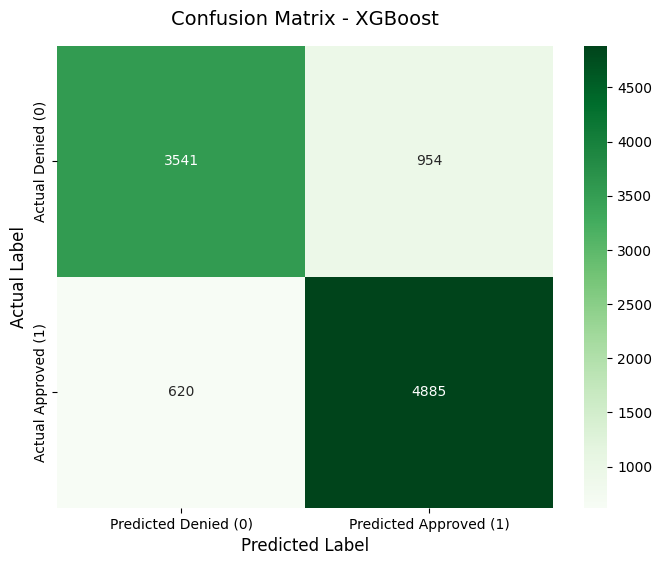

In [38]:
#XGBBOOST Classification Report

# 4. Print the XGBoost Classification Report
print("Classification Report - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

# 5. Plot the Confusion Matrix for XGBoost
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Greens", # Using Greens to differentiate from your Blues
            xticklabels=["Predicted Denied (0)", "Predicted Approved (1)"],
            yticklabels=["Actual Denied (0)", "Actual Approved (1)"])

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Confusion Matrix - XGBoost", fontsize=14, pad=15)
plt.show()

In [40]:
import joblib

# FOR LOGISTIC MODEL
joblib.dump(
    {
        "model": log_reg_model,
        "le": label_encoder,
        "scaler": scaler,
        "columns": list(X.columns)
    }, 'LoanStatusLogReg.pkl'
)
# # FOR XGBBOOST
# joblib.dump(
#     {
#         "model": xgb_model,
#         "le": label_encoder,
#         "scaler": scaler,
#         "columns": list(X.columns)
#     }, 'LoanStatusXGB.pkl'
# )

['LoanStatusLogReg.pkl']